# SBFL-for-FOL: Spectrum-Based Fault Localization for NL→FOL Translation

This notebook demonstrates the **SBFL-for-FOL** pipeline: a 6-phase method that applies
Spectrum-Based Fault Localization (SBFL) — a classical software testing technique — to
pinpoint and repair faulty components in NL→FOL translations.

**Pipeline overview:**
- **Phase 0 (Locality Pilot):** Verify that most translation errors are local (≤2 faulty components)
- **Phase 1 (Aligned Translation):** Produce span-tagged component decompositions
- **Phase 2+3 (Probe Bank):** Build a suite of Z3 model-checking + analytical probes
- **Phase 4 (SBFL Ranking):** Apply Ochiai/Tarantula/DStar suspiciousness metrics
- **Phase 5 (Targeted Repair):** SBFL-guided repair vs blind regeneration
- **Phase 6 (Ablations):** Probe count curves, noise injection, metric comparison

**Demo mode:** This notebook loads pre-computed translations from `mini_demo_data.json`
and re-runs the deterministic phases (probes + SBFL ranking + ablations) locally —
no API key required.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# z3-solver, loguru, zss — NOT pre-installed on Colab, always install
_pip('z3-solver==4.14.1.0')
_pip('loguru==0.7.3')
_pip('zss==1.2.0')

# numpy, matplotlib, nltk — pre-installed on Colab, install locally to match
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'nltk==3.9.1')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import re
import sys
import time
from collections import Counter
from copy import deepcopy
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import nltk
import numpy as np
import z3
from loguru import logger

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-e70e3d-diagnosing-the-formula-locality-gated-sp/main/round-1/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded data: {data['metadata']['method_name']}")
print(f"Examples: {len(data['datasets'][0]['examples'])}")

Loaded data: SBFL-for-FOL
Examples: 3


In [5]:
# ── Config (minimum values for demo; original full-run values shown in comments) ──
MAX_SENTENCES = 3        # original: 120
DOMAIN_SIZE   = 4        # original: 6  (Z3 bounded model domain size)
Z3_TIMEOUT_MS = 2000     # original: 5000

# Phase 6 ablation grids
K_VALUES     = [2, 5]           # original: [5, 10, 20]
NOISE_PCTS   = [0, 10, 20]      # original: [0, 10, 20, 30, 40]

## FOL Parser

A hand-written recursive-descent parser converts FOL strings (with Unicode symbols
like `∀`, `∃`, `¬`, `∧`) into an AST of `FOLNode` objects. Each predicate and
quantifier node receives a unique `component_id` — the unit of analysis for SBFL.

In [6]:
class ParseError(Exception):
    pass


class FOLNode:
    __slots__ = ["ntype", "label", "children", "component_id", "nesting_depth"]

    def __init__(self, ntype: str, label: str, children: list | None = None):
        self.ntype = ntype  # forall|exists|not|and|or|impl|iff|xor|pred|var|const
        self.label = label
        self.children: list["FOLNode"] = children or []
        self.component_id = ""
        self.nesting_depth = 0

    def __repr__(self):
        if self.children:
            return f"FOLNode({self.ntype},{self.label!r},{self.children})"
        return f"FOLNode({self.ntype},{self.label!r})"

    def __eq__(self, other):
        if not isinstance(other, FOLNode):
            return False
        return self.ntype == other.ntype and self.label == other.label and self.children == other.children


def _tokenize_fol(s: str) -> list[str]:
    """Tokenize FOL string with Unicode logic symbols."""
    s = s.strip()
    # Rewrite infix equality: x=y → Eq(x,y) before other replacements
    s = re.sub(r'(\w+)\s*=\s*(\w+)', r'Eq(\1,\2)', s)
    # Unicode symbol → ASCII token
    replacements = [
        ("∀", " FORALL "), ("∃", " EXISTS "),
        ("¬", " NOT "), ("∧", " AND "), ("∨", " OR "),
        ("→", " IMPL "), ("↔", " IFF "), ("⊕", " XOR "),
        ("->", " IMPL "), ("<->", " IFF "),
        ("(", " ( "), (")", " ) "), (",", " , "),
    ]
    for sym, tok in replacements:
        s = s.replace(sym, tok)
    tokens = s.split()
    return [t for t in tokens if t]


class FOLParser:
    def __init__(self, tokens: list[str]):
        self.tokens = tokens
        self.pos = 0
        self._component_counter = [0]

    def peek(self) -> str | None:
        if self.pos < len(self.tokens):
            return self.tokens[self.pos]
        return None

    def consume(self, expected: str | None = None) -> str:
        if self.pos >= len(self.tokens):
            raise ParseError(f"Unexpected end of input (expected {expected!r})")
        tok = self.tokens[self.pos]
        if expected and tok != expected:
            raise ParseError(f"Expected {expected!r}, got {tok!r} at pos {self.pos}")
        self.pos += 1
        return tok

    def _new_cid(self) -> str:
        cid = f"c{self._component_counter[0]}"
        self._component_counter[0] += 1
        return cid

    def parse(self) -> FOLNode:
        node = self.parse_iff()
        if self.pos < len(self.tokens):
            raise ParseError(f"Unexpected token {self.tokens[self.pos]!r} at pos {self.pos}")
        return node

    def parse_iff(self) -> FOLNode:
        left = self.parse_impl()
        while self.peek() in ("IFF",):
            self.consume()
            right = self.parse_impl()
            node = FOLNode("iff", "↔", [left, right])
            left = node
        return left

    def parse_impl(self) -> FOLNode:
        left = self.parse_or()
        while self.peek() == "IMPL":
            self.consume()
            right = self.parse_or()
            node = FOLNode("impl", "→", [left, right])
            left = node
        return left

    def parse_or(self) -> FOLNode:
        left = self.parse_and()
        while self.peek() == "OR":
            self.consume()
            right = self.parse_and()
            node = FOLNode("or", "∨", [left, right])
            left = node
        return left

    def parse_and(self) -> FOLNode:
        left = self.parse_unary()
        while self.peek() == "AND":
            self.consume()
            right = self.parse_unary()
            node = FOLNode("and", "∧", [left, right])
            left = node
        return left

    def parse_unary(self) -> FOLNode:
        tok = self.peek()
        if tok == "NOT":
            self.consume()
            child = self.parse_unary()
            return FOLNode("not", "¬", [child])
        if tok == "FORALL":
            self.consume()
            var = self.consume()
            if self.peek() == "(":
                self.consume("(")
                body = self.parse_iff()
                self.consume(")")
            else:
                body = self.parse_unary()
            node = FOLNode("forall", var, [body])
            node.component_id = self._new_cid()
            return node
        if tok == "EXISTS":
            self.consume()
            var = self.consume()
            if self.peek() == "(":
                self.consume("(")
                body = self.parse_iff()
                self.consume(")")
            else:
                body = self.parse_unary()
            node = FOLNode("exists", var, [body])
            node.component_id = self._new_cid()
            return node
        if tok == "XOR":
            self.consume()
            left = self.parse_unary()
            right = self.parse_unary()
            return FOLNode("xor", "⊕", [left, right])
        return self.parse_atom()

    def parse_atom(self) -> FOLNode:
        tok = self.peek()
        if tok == "(":
            self.consume("(")
            node = self.parse_iff()
            self.consume(")")
            return node
        if tok is None:
            raise ParseError("Unexpected end of input")
        if tok == "EQ":
            self.consume()
            return FOLNode("pred", "EQ", [])
        if tok[0].isupper():
            self.consume()
            if self.peek() == "(":
                self.consume("(")
                args = []
                while self.peek() not in (None, ")"):
                    arg_tok = self.tokens[self.pos]
                    self.pos += 1
                    args.append(FOLNode("var", arg_tok))
                    if self.peek() == ",":
                        self.consume(",")
                self.consume(")")
                node = FOLNode("pred", tok, args)
                node.component_id = self._new_cid()
                return node
            else:
                node = FOLNode("pred", tok, [])
                node.component_id = self._new_cid()
                return node
        self.consume()
        return FOLNode("var", tok)


def parse_fol(s: str) -> FOLNode:
    """Parse a FOL string to AST. Raises ParseError on failure."""
    s = s.strip()
    if not s:
        raise ParseError("Empty formula")
    tokens = _tokenize_fol(s)
    if not tokens:
        raise ParseError("No tokens")
    parser = FOLParser(tokens)
    tree = parser.parse()
    _assign_nesting_depth(tree, 0)
    return tree


def _assign_nesting_depth(node: FOLNode, depth: int):
    node.nesting_depth = depth
    child_depth = depth + (1 if node.ntype in ("forall", "exists") else 0)
    for c in node.children:
        _assign_nesting_depth(c, child_depth)


def canonical_rename(tree: FOLNode) -> FOLNode:
    """Rename bound variables to x0, x1, ... in DFS order. Returns new tree."""
    counter = [0]
    rename_map: dict[str, str] = {}

    def _rename(node: FOLNode) -> FOLNode:
        new_children = []
        if node.ntype in ("forall", "exists"):
            old_var = node.label
            new_var = f"x{counter[0]}"
            counter[0] += 1
            old_val = rename_map.get(old_var)
            rename_map[old_var] = new_var
            for c in node.children:
                new_children.append(_rename(c))
            rename_map[old_var] = old_val  # restore
            new_node = FOLNode(node.ntype, new_var, new_children)
            new_node.component_id = node.component_id
            new_node.nesting_depth = node.nesting_depth
            return new_node
        elif node.ntype == "var":
            new_label = rename_map.get(node.label, node.label)
            return FOLNode("var", new_label)
        else:
            for c in node.children:
                new_children.append(_rename(c))
            new_node = FOLNode(node.ntype, node.label, new_children)
            new_node.component_id = node.component_id
            new_node.nesting_depth = node.nesting_depth
            return new_node

    return _rename(tree)


def fol_to_string(node: FOLNode) -> str:
    """Convert FOLNode back to string."""
    nt = node.ntype
    if nt == "var":   return node.label
    if nt == "const": return node.label
    if nt == "pred":
        if node.children:
            args = ",".join(fol_to_string(c) for c in node.children)
            return f"{node.label}({args})"
        return node.label
    if nt == "not":   return f"¬{fol_to_string(node.children[0])}"
    if nt == "forall": return f"∀{node.label}({fol_to_string(node.children[0])})"
    if nt == "exists": return f"∃{node.label}({fol_to_string(node.children[0])})"
    if nt == "and":   return f"({fol_to_string(node.children[0])} ∧ {fol_to_string(node.children[1])})"
    if nt == "or":    return f"({fol_to_string(node.children[0])} ∨ {fol_to_string(node.children[1])})"
    if nt == "impl":  return f"({fol_to_string(node.children[0])} → {fol_to_string(node.children[1])})"
    if nt == "iff":   return f"({fol_to_string(node.children[0])} ↔ {fol_to_string(node.children[1])})"
    if nt == "xor":   return f"({fol_to_string(node.children[0])} ⊕ {fol_to_string(node.children[1])})"
    return node.label


def get_fault_components(tree: FOLNode) -> list[FOLNode]:
    """Get fault-site components: predicate nodes + quantifier nodes."""
    result = []

    def _walk(node: FOLNode):
        if node.ntype in ("pred", "forall", "exists") and node.component_id:
            result.append(node)
        for c in node.children:
            _walk(c)

    _walk(tree)
    return result


def get_all_components(tree: FOLNode) -> list[FOLNode]:
    return get_fault_components(tree)


print("FOL parser loaded. Quick test:")
test_tree = parse_fol("∀x (DrinkRegularly(x, coffee) → IsDependentOn(x, caffeine))")
print(f"  Parsed OK, components: {[n.component_id for n in get_fault_components(test_tree)]}")

FOL parser loaded. Quick test:
  Parsed OK, components: ['c2', 'c0', 'c1']


## Z3 Bounded Model Checking

FOL formulas are compiled to Z3 expressions over a finite domain of size `DOMAIN_SIZE`.
This supports three probe types:
- **conjunct_drop:** For `A ∧ B`, verify `(A ∧ B) ⊨ A` and `⊨ B` separately
- **negation_consistency:** Check the formula is satisfiable (not a tautological contradiction)
- **equivalence:** Check if two formulas are logically equivalent

In [7]:
z3.set_param("timeout", Z3_TIMEOUT_MS)


def _make_domain(size: int) -> tuple[z3.SortRef, list[z3.ExprRef]]:
    dom_sort = z3.DeclareSort(f"Dom{size}")
    consts = [z3.Const(f"d{i}", dom_sort) for i in range(size)]
    return dom_sort, consts


def fol_to_z3(node: FOLNode, pred_arities: dict[str, int], bound_vars: dict[str, z3.ExprRef],
               dom_sort: z3.SortRef, domain: list[z3.ExprRef]) -> z3.ExprRef | None:
    """Convert FOLNode to z3 expression. Returns None if unsupported."""
    nt = node.ntype
    try:
        if nt == "pred":
            name = node.label
            n_args = len(node.children)
            if name not in pred_arities:
                fn_sort = [dom_sort] * n_args + [z3.BoolSort()]
                pred_arities[name] = n_args
                pred_fn = z3.Function(name, *fn_sort)
            else:
                stored = pred_arities[name]
                if stored != n_args:
                    return None
                fn_sort = [dom_sort] * n_args + [z3.BoolSort()]
                pred_fn = z3.Function(name, *fn_sort)
            args = []
            for c in node.children:
                if c.ntype == "var":
                    if c.label in bound_vars:
                        args.append(bound_vars[c.label])
                    else:
                        args.append(domain[0])
                else:
                    args.append(domain[0])
            if n_args == 0:
                return pred_fn()
            return pred_fn(*args)
        elif nt == "not":
            inner = fol_to_z3(node.children[0], pred_arities, bound_vars, dom_sort, domain)
            if inner is None: return None
            return z3.Not(inner)
        elif nt == "and":
            l = fol_to_z3(node.children[0], pred_arities, bound_vars, dom_sort, domain)
            r = fol_to_z3(node.children[1], pred_arities, bound_vars, dom_sort, domain)
            if l is None or r is None: return None
            return z3.And(l, r)
        elif nt == "or":
            l = fol_to_z3(node.children[0], pred_arities, bound_vars, dom_sort, domain)
            r = fol_to_z3(node.children[1], pred_arities, bound_vars, dom_sort, domain)
            if l is None or r is None: return None
            return z3.Or(l, r)
        elif nt == "impl":
            l = fol_to_z3(node.children[0], pred_arities, bound_vars, dom_sort, domain)
            r = fol_to_z3(node.children[1], pred_arities, bound_vars, dom_sort, domain)
            if l is None or r is None: return None
            return z3.Implies(l, r)
        elif nt == "iff":
            l = fol_to_z3(node.children[0], pred_arities, bound_vars, dom_sort, domain)
            r = fol_to_z3(node.children[1], pred_arities, bound_vars, dom_sort, domain)
            if l is None or r is None: return None
            return l == r
        elif nt == "forall":
            var = z3.Const(node.label, dom_sort)
            new_bv = {**bound_vars, node.label: var}
            body = fol_to_z3(node.children[0], pred_arities, new_bv, dom_sort, domain)
            if body is None: return None
            return z3.ForAll([var], body)
        elif nt == "exists":
            var = z3.Const(node.label, dom_sort)
            new_bv = {**bound_vars, node.label: var}
            body = fol_to_z3(node.children[0], pred_arities, new_bv, dom_sort, domain)
            if body is None: return None
            return z3.Exists([var], body)
        elif nt in ("var", "const"):
            return bound_vars.get(node.label, domain[0])
    except Exception:
        return None
    return None


def z3_check(formula_str: str, *, check_sat: bool = False) -> str:
    """Check SAT/UNSAT. Returns 'sat'|'unsat'|'inconclusive'."""
    try:
        dom_sort = z3.DeclareSort("Dom_chk")
        domain = [z3.Const(f"d_chk_{i}", dom_sort) for i in range(DOMAIN_SIZE)]
        pred_arities: dict[str, int] = {}
        tree = parse_fol(formula_str)
        expr = fol_to_z3(tree, pred_arities, {}, dom_sort, domain)
        if expr is None: return "inconclusive"
        solver = z3.Solver()
        solver.set("timeout", Z3_TIMEOUT_MS)
        if check_sat:
            solver.add(expr)
        else:
            solver.add(z3.Not(expr))
        result = solver.check()
        if result == z3.sat:   return "sat"
        elif result == z3.unsat: return "unsat"
        return "inconclusive"
    except Exception:
        return "inconclusive"


def z3_check_entailment(antecedent: str, consequent: str) -> str:
    """Check antecedent |= consequent. Returns 'pass'|'fail'|'inconclusive'."""
    try:
        dom_sort = z3.DeclareSort("Dom_ent")
        domain = [z3.Const(f"d_ent_{i}", dom_sort) for i in range(DOMAIN_SIZE)]
        pred_arities: dict[str, int] = {}
        ant_tree = parse_fol(antecedent)
        con_tree = parse_fol(consequent)
        ant_expr = fol_to_z3(ant_tree, pred_arities, {}, dom_sort, domain)
        con_expr = fol_to_z3(con_tree, pred_arities, {}, dom_sort, domain)
        if ant_expr is None or con_expr is None: return "inconclusive"
        solver = z3.Solver()
        solver.set("timeout", Z3_TIMEOUT_MS)
        solver.add(ant_expr)
        solver.add(z3.Not(con_expr))
        result = solver.check()
        if result == z3.unsat: return "pass"
        elif result == z3.sat: return "fail"
        return "inconclusive"
    except Exception:
        return "inconclusive"


def z3_check_equivalence(fol1: str, fol2: str) -> str:
    """Check if two FOL formulas are logically equivalent."""
    try:
        dom_sort = z3.DeclareSort("Dom_eq")
        domain = [z3.Const(f"d_eq_{i}", dom_sort) for i in range(DOMAIN_SIZE)]
        pred_arities: dict[str, int] = {}
        t1 = parse_fol(fol1)
        t2 = parse_fol(fol2)
        e1 = fol_to_z3(t1, pred_arities, {}, dom_sort, domain)
        e2 = fol_to_z3(t2, pred_arities, {}, dom_sort, domain)
        if e1 is None or e2 is None: return "inconclusive"
        solver = z3.Solver()
        solver.set("timeout", Z3_TIMEOUT_MS)
        solver.add(z3.Not(e1 == e2))
        result = solver.check()
        if result == z3.unsat: return "equiv"
        elif result == z3.sat: return "not_equiv"
        return "inconclusive"
    except Exception:
        return "inconclusive"


print("Z3 model checking loaded.")

Z3 model checking loaded.


## Analytical Probes (Phases 2+3)

Four deterministic probes check structural properties without Z3:
1. **well_formedness** – formula parses without error
2. **free_variables** – no unbound variables
3. **arity_consistency** – each predicate always called with the same arity
4. **scope_balance** – each quantifier actually uses its bound variable

Plus two Z3 probes:
- **conjunct_drop** – each conjunct of `A ∧ B` is entailed by the whole
- **negation_consistency** – formula is satisfiable

In [8]:
def probe_well_formedness(fol_str: str) -> dict:
    """Probe 5: Check if formula parses without error."""
    try:
        parse_fol(fol_str)
        return {"verdict": "pass", "implicated_components": []}
    except ParseError as e:
        return {"verdict": "fail", "implicated_components": ["all"], "detail": str(e)}


def probe_free_variables(fol_str: str) -> dict:
    """Probe 6: Check for unbound variables."""
    try:
        tree = parse_fol(fol_str)
        offenders = []

        def _walk(node: FOLNode, bound: set[str]):
            if node.ntype in ("forall", "exists"):
                new_bound = bound | {node.label}
                for c in node.children:
                    _walk(c, new_bound)
            elif node.ntype == "var":
                if node.label[0].islower() and node.label not in bound:
                    offenders.append(node.label)
            elif node.ntype == "pred":
                for c in node.children:
                    _walk(c, bound)
                    if node.component_id and c.ntype == "var" and c.label[0].islower() and c.label not in bound:
                        if node.component_id not in offenders:
                            offenders.append(node.component_id)
            else:
                for c in node.children:
                    _walk(c, bound)

        _walk(tree, set())
        if offenders:
            return {"verdict": "fail", "implicated_components": offenders[:3]}
        return {"verdict": "pass", "implicated_components": []}
    except ParseError:
        return {"verdict": "fail", "implicated_components": ["all"]}


def probe_arity_consistency(fol_str: str) -> dict:
    """Probe 7: Check predicate arity consistency."""
    try:
        tree = parse_fol(fol_str)
        arity_map: dict[str, tuple[int, str]] = {}
        offenders = []

        def _walk(node: FOLNode):
            if node.ntype == "pred":
                n = len(node.children)
                if node.label in arity_map:
                    expected, cid = arity_map[node.label]
                    if expected != n:
                        offenders.append(node.component_id or cid)
                else:
                    arity_map[node.label] = (n, node.component_id)
            for c in node.children:
                _walk(c)

        _walk(tree)
        if offenders:
            return {"verdict": "fail", "implicated_components": offenders}
        return {"verdict": "pass", "implicated_components": []}
    except ParseError:
        return {"verdict": "fail", "implicated_components": ["all"]}


def probe_scope_balance(fol_str: str) -> dict:
    """Probe 8: Check quantifier scope balance."""
    try:
        tree = parse_fol(fol_str)
        issues = []

        def _check_scope(node: FOLNode, bound_here: set[str]) -> set[str]:
            """Returns set of variables used in this subtree."""
            used = set()
            if node.ntype in ("forall", "exists"):
                var = node.label
                child_used = _check_scope(node.children[0], bound_here | {var})
                if var not in child_used and node.children:
                    issues.append(node.component_id)
                used |= child_used - {var}
            elif node.ntype == "var":
                used.add(node.label)
            elif node.ntype == "pred":
                for c in node.children:
                    used |= _check_scope(c, bound_here)
            else:
                for c in node.children:
                    used |= _check_scope(c, bound_here)
            return used

        _check_scope(tree, set())
        if issues:
            return {"verdict": "fail", "implicated_components": issues}
        return {"verdict": "pass", "implicated_components": []}
    except ParseError:
        return {"verdict": "fail", "implicated_components": ["all"]}


def run_all_analytical_probes(fol_str: str) -> list[dict]:
    """Run probes 5-8 and return list of probe results."""
    probes = []
    for probe_fn, probe_name in [
        (probe_well_formedness, "well_formedness"),
        (probe_free_variables, "free_variables"),
        (probe_arity_consistency, "arity_consistency"),
        (probe_scope_balance, "scope_balance"),
    ]:
        result = probe_fn(fol_str)
        result["probe_name"] = probe_name
        result["probe_type"] = "analytical"
        probes.append(result)
    return probes


def run_conjunct_drop_probes(fol_str: str) -> list[dict]:
    """Probe 1: For conjunctive formulas, check each conjunct is entailed."""
    try:
        tree = parse_fol(fol_str)

        def get_conjuncts(node: FOLNode) -> list[FOLNode]:
            if node.ntype == "and":
                return get_conjuncts(node.children[0]) + get_conjuncts(node.children[1])
            return [node]

        conjuncts = get_conjuncts(tree)
        if len(conjuncts) < 2:
            return []

        probes = []
        for conj in conjuncts:
            conj_str = fol_to_string(conj)
            verdict = z3_check_entailment(fol_str, conj_str)
            comp_ids = [c.component_id for c in get_fault_components(conj) if c.component_id]
            probes.append({
                "probe_name": "conjunct_drop",
                "probe_type": "z3",
                "verdict": "pass" if verdict == "pass" else ("fail" if verdict == "fail" else "inconclusive"),
                "implicated_components": comp_ids,
            })
        return probes
    except Exception:
        return []


def run_negation_probe(fol_str: str) -> list[dict]:
    """Probe 2: Check formula is not self-contradictory."""
    try:
        result = z3_check(fol_str, check_sat=True)
        verdict = "pass" if result == "sat" else ("fail" if result == "unsat" else "inconclusive")
        return [{
            "probe_name": "negation_consistency",
            "probe_type": "z3",
            "verdict": verdict,
            "implicated_components": [],
        }]
    except Exception:
        return []


def run_probes_for_sentence(fol_str: str) -> list[dict]:
    """Run all probes for a given FOL formula."""
    probes = []
    probes.extend(run_all_analytical_probes(fol_str))
    probes.extend(run_conjunct_drop_probes(fol_str))
    probes.extend(run_negation_probe(fol_str))
    return probes


def compute_probe_verdict_rate(probes: list[dict]) -> dict:
    if not probes:
        return {"overall": 0.0, "by_type": {}}
    by_type: dict[str, list] = {}
    for p in probes:
        pt = p.get("probe_type", "unknown")
        by_type.setdefault(pt, []).append(p)
    total = len(probes)
    definitive = sum(1 for p in probes if p["verdict"] != "inconclusive")
    result = {"overall": definitive / total if total else 0.0, "by_type": {}}
    for pt, ps in by_type.items():
        d = sum(1 for p in ps if p["verdict"] != "inconclusive")
        result["by_type"][pt] = d / len(ps) if ps else 0.0
    return result


print("Probe functions loaded.")

Probe functions loaded.


## Phase 0: Locality Pilot

For each NL sentence, we have a pre-computed candidate FOL translation and the gold FOL.
We check how many components differ between them — the **locality** of the fault.
The key hypothesis: if ≥70% of errors are local (≤2 faulty components), SBFL is viable.

In [9]:
def _count_component_mismatches(gold: FOLNode, cand: FOLNode) -> int:
    """Count component-level mismatches between two aligned trees."""
    gold_comps = [f"{n.ntype}:{n.label}" for n in get_fault_components(gold)]
    cand_comps = [f"{n.ntype}:{n.label}" for n in get_fault_components(cand)]
    max_len = max(len(gold_comps), len(cand_comps))
    if max_len == 0:
        return 0
    matches = sum(a == b for a, b in zip(gold_comps, cand_comps))
    return max_len - matches


# ── Load sentences from pre-computed demo data (no API calls needed) ──
examples = data["datasets"][0]["examples"][:MAX_SENTENCES]
sentences = [
    {
        "nl": ex["input"],
        "gold_fol": ex["output"],
        "candidate_fol": ex["predict_our_method"],  # pre-computed by the full run
        "is_wrong": ex["metadata_is_wrong"],
        "n_faulty": ex["metadata_n_faulty"],
    }
    for ex in examples
]

wrong = [s for s in sentences if s["is_wrong"]]
correct = [s for s in sentences if not s["is_wrong"]]
locality_dist = dict(Counter(s["n_faulty"] for s in wrong))
local_errors = sum(1 for s in wrong if s["n_faulty"] <= 2 and s["n_faulty"] < 99)
locality_frac = local_errors / len(wrong) if wrong else 0.0
locality_gate = locality_frac >= 0.70

print(f"Phase 0: {len(wrong)}/{len(sentences)} wrong")
print(f"  Locality fraction: {locality_frac:.2%}  (gate: {'PASS' if locality_gate else 'FAIL'})")
print(f"  Locality distribution: {locality_dist}")
print()
print("Note: demo uses 3 examples; full-run locality_fraction from 120 examples = "
      f"{data['metadata']['locality_fraction']:.2%}")

# Work on wrong sentences for Phase 2+
local_subset = [s for s in wrong if s["n_faulty"] <= 2 and s["n_faulty"] < 99]
if not local_subset:
    local_subset = wrong[:40]
print(f"\nLocal subset size (demo): {len(local_subset)}")

Phase 0: 3/3 wrong
  Locality fraction: 0.00%  (gate: FAIL)
  Locality distribution: {3: 3}

Note: demo uses 3 examples; full-run locality_fraction from 120 examples = 28.95%

Local subset size (demo): 3


## Phases 2+3: Build the Probe Bank

For each sentence in the local subset, we:
1. Parse the candidate FOL into an AST
2. Extract component IDs (predicates + quantifiers)
3. Run all analytical + Z3 probes
4. Determine **true fault components** by comparing parsed gold vs candidate ASTs

In [10]:
sentence_results = []
all_probe_verdicts = []

for s in local_subset:
    fol_str = s.get("candidate_fol", "")
    if not fol_str:
        continue

    probes = run_probes_for_sentence(fol_str)

    # Determine component IDs from the formula
    try:
        tree = parse_fol(fol_str)
        comp_nodes = get_fault_components(tree)
        component_ids = [n.component_id for n in comp_nodes if n.component_id]
    except Exception:
        comp_nodes = []
        component_ids = []

    # True fault components: from AST diff vs gold
    true_faults = []
    try:
        gold_tree = canonical_rename(parse_fol(s["gold_fol"]))
        cand_tree = canonical_rename(parse_fol(fol_str))
        gold_comps = get_fault_components(gold_tree)
        cand_comps = get_fault_components(cand_tree)
        # Mark mismatched positions as faults
        for i, (gc, cc) in enumerate(zip(gold_comps, cand_comps)):
            if fol_to_string(gc) != fol_to_string(cc) and i < len(component_ids):
                true_faults.append(component_ids[i])
        if not true_faults and component_ids:
            true_faults = [component_ids[0]]
    except Exception:
        if component_ids:
            true_faults = [component_ids[0]]

    all_probe_verdicts.extend(probes)
    sentence_results.append({
        "nl": s["nl"],
        "gold_fol": s["gold_fol"],
        "candidate_fol": fol_str,
        "probes": probes,
        "component_ids": component_ids,
        "component_nodes": comp_nodes,
        "true_fault_components": true_faults,
        "n_faulty": s.get("n_faulty", 0),
        "aligned_components": [],
    })

probe_verdict_rate = compute_probe_verdict_rate(all_probe_verdicts)
print(f"Probe verdict rate: {probe_verdict_rate}")
print(f"Total probes: {len(all_probe_verdicts)} across {len(sentence_results)} sentences")

Probe verdict rate: {'overall': 1.0, 'by_type': {'analytical': 1.0, 'z3': 1.0}}
Total probes: 15 across 3 sentences


## Phase 4: SBFL Suspiciousness Ranking

A probe×component binary **coverage matrix** `M` and failure vector `f` are built:
- `M[i,j] = 1` if probe `i` implicates component `j`
- `f[i] = 1` if probe `i` failed

Three classic SBFL metrics then score each component:
- **Ochiai:** `nf_c / sqrt(nf * (nf_c + np_c))`
- **Tarantula:** `(nf_c/nf) / ((nf_c/nf) + (np_c/np))`
- **DStar:** `nf_c² / (np_c + nf - nf_c)`

The top-ranked component is compared against the true fault to measure **Top-1 accuracy**.

In [11]:
def build_coverage_matrix(
    probes: list[dict], component_ids: list[str]
) -> tuple[np.ndarray, np.ndarray]:
    """Build probe×component binary matrix and failure vector."""
    n_probes = len(probes)
    n_comps = len(component_ids)
    M = np.zeros((n_probes, n_comps), dtype=float)
    failure = np.zeros(n_probes, dtype=float)
    comp_idx = {c: i for i, c in enumerate(component_ids)}

    for i, probe in enumerate(probes):
        if probe["verdict"] == "fail":
            failure[i] = 1.0
        for cid in probe.get("implicated_components", []):
            if cid in comp_idx:
                M[i, comp_idx[cid]] = 1.0
            elif cid == "all":
                M[i, :] = 1.0
    return M, failure


def ochiai(M: np.ndarray, failure: np.ndarray) -> np.ndarray:
    nf = failure.sum()
    scores = np.zeros(M.shape[1])
    for j in range(M.shape[1]):
        nf_c = (M[:, j] * failure).sum()
        np_c = (M[:, j] * (1 - failure)).sum()
        denom = math.sqrt(nf * (nf_c + np_c)) if nf > 0 else 0
        scores[j] = nf_c / denom if denom > 0 else 0.0
    return scores


def tarantula(M: np.ndarray, failure: np.ndarray) -> np.ndarray:
    nf = failure.sum()
    np_total = (1 - failure).sum()
    scores = np.zeros(M.shape[1])
    for j in range(M.shape[1]):
        nf_c = (M[:, j] * failure).sum()
        np_c = (M[:, j] * (1 - failure)).sum()
        nf_ratio = nf_c / nf if nf > 0 else 0
        np_ratio = np_c / np_total if np_total > 0 else 0
        denom = nf_ratio + np_ratio + 1e-10
        scores[j] = nf_ratio / denom
    return scores


def dstar(M: np.ndarray, failure: np.ndarray, star: int = 2) -> np.ndarray:
    nf = failure.sum()
    scores = np.zeros(M.shape[1])
    for j in range(M.shape[1]):
        nf_c = (M[:, j] * failure).sum()
        np_c = (M[:, j] * (1 - failure)).sum()
        denom = np_c + (nf - nf_c) + 1e-10
        scores[j] = (nf_c ** star) / denom
    return scores


def rank_components(scores: np.ndarray, component_ids: list[str], nodes: list[FOLNode]) -> list[str]:
    """Rank components by score desc, tie-break by nesting depth."""
    depth_map = {n.component_id: n.nesting_depth for n in nodes if n.component_id}
    order = sorted(
        range(len(component_ids)),
        key=lambda j: (-scores[j], -depth_map.get(component_ids[j], 0)),
    )
    return [component_ids[i] for i in order]


def compute_localization_metrics(
    ranked_components: list[str], true_fault_components: list[str]
) -> dict:
    """Compute Top-1, Top-3, wasted-effort given ranked component list."""
    if not true_fault_components or not ranked_components:
        return {"top1": False, "top3": False, "wasted_effort": 1.0}
    true_set = set(true_fault_components)
    top1 = ranked_components[0] in true_set if ranked_components else False
    top3 = any(c in true_set for c in ranked_components[:3])
    first_rank = next(
        (i for i, c in enumerate(ranked_components) if c in true_set), len(ranked_components)
    )
    we = first_rank / len(ranked_components) if ranked_components else 1.0
    return {"top1": top1, "top3": top3, "wasted_effort": we}


# ── Run Phase 4 ──
ochiai_metrics, tarantula_metrics, dstar_metrics, random_metrics = [], [], [], []

for sr in sentence_results:
    probes = sr["probes"]
    true_faults = sr["true_fault_components"]
    comps = sr["component_ids"]
    comp_nodes = sr["component_nodes"]
    if not comps or not true_faults:
        continue

    M, fvec = build_coverage_matrix(probes, comps)

    scores_och = ochiai(M, fvec)
    ranked_och = rank_components(scores_och, comps, comp_nodes)
    ochiai_metrics.append(compute_localization_metrics(ranked_och, true_faults))

    scores_tar = tarantula(M, fvec)
    ranked_tar = rank_components(scores_tar, comps, comp_nodes)
    tarantula_metrics.append(compute_localization_metrics(ranked_tar, true_faults))

    scores_ds = dstar(M, fvec)
    ranked_ds = rank_components(scores_ds, comps, comp_nodes)
    dstar_metrics.append(compute_localization_metrics(ranked_ds, true_faults))

    n = len(comps)
    random_metrics.append({
        "top1": 1.0 / n if n > 0 else 0.0,
        "top3": min(3.0 / n, 1.0) if n > 0 else 0.0,
        "wasted_effort": 0.5,
    })
    sr["ochiai_ranked"] = ranked_och
    sr["ochiai_scores"] = scores_och.tolist()


def aggregate(metrics: list[dict]) -> dict:
    if not metrics:
        return {"top1": 0.0, "top3": 0.0, "wasted_effort": 1.0}
    return {
        "top1": float(np.mean([m["top1"] for m in metrics])),
        "top3": float(np.mean([m["top3"] for m in metrics])),
        "wasted_effort": float(np.mean([m["wasted_effort"] for m in metrics])),
    }


localization_results = {
    "local_subset_size": len(sentence_results),
    "ochiai": aggregate(ochiai_metrics),
    "tarantula": aggregate(tarantula_metrics),
    "dstar": aggregate(dstar_metrics),
    "baseline_random": aggregate(random_metrics),
}
print("Phase 4 localization results (demo):")
for method, res in localization_results.items():
    if isinstance(res, dict):
        print(f"  {method}: top1={res['top1']:.2%}  top3={res['top3']:.2%}  wasted_effort={res['wasted_effort']:.3f}")

Phase 4 localization results (demo):
  ochiai: top1=100.00%  top3=100.00%  wasted_effort=0.000
  tarantula: top1=100.00%  top3=100.00%  wasted_effort=0.000
  dstar: top1=100.00%  top3=100.00%  wasted_effort=0.000
  baseline_random: top1=27.78%  top3=83.33%  wasted_effort=0.500


## Phase 6: Ablations

Two ablation studies:
1. **Probe count curve** – vary how many probes are used (first `k`), measure Ochiai Top-1
2. **Alignment noise** – flip `noise_pct%` of coverage matrix entries randomly, measure degradation

In [12]:
def ablation_probe_count(
    sentence_results: list[dict], k_values: list[int]
) -> list[dict]:
    """Ablation 1: Vary probe count k, measure Ochiai Top-1."""
    rows = []
    for k in k_values:
        top1_mixed, top1_z3_only, top1_analytical_only = [], [], []
        for sr in sentence_results:
            probes = sr.get("probes", [])
            true_faults = sr.get("true_fault_components", [])
            comps = sr.get("component_ids", [])
            if not comps or not true_faults:
                continue
            sampled = probes[:k] if len(probes) >= k else probes
            # Mixed
            M, fvec = build_coverage_matrix(sampled, comps)
            scores = ochiai(M, fvec)
            ranked = rank_components(scores, comps, sr.get("component_nodes", []))
            metrics = compute_localization_metrics(ranked, true_faults)
            top1_mixed.append(metrics["top1"])
            # Z3 probes only
            z3_probes = [p for p in sampled if p.get("probe_type") == "z3"][:k]
            if z3_probes:
                M2, fvec2 = build_coverage_matrix(z3_probes, comps)
                s2 = ochiai(M2, fvec2)
                r2 = rank_components(s2, comps, sr.get("component_nodes", []))
                top1_z3_only.append(compute_localization_metrics(r2, true_faults)["top1"])
            # Analytical probes only
            an_probes = [p for p in sampled if p.get("probe_type") == "analytical"][:k]
            if an_probes:
                M3, fvec3 = build_coverage_matrix(an_probes, comps)
                s3 = ochiai(M3, fvec3)
                r3 = rank_components(s3, comps, sr.get("component_nodes", []))
                top1_analytical_only.append(compute_localization_metrics(r3, true_faults)["top1"])
        rows.append({
            "k": k,
            "ochiai_top1": float(np.mean(top1_mixed)) if top1_mixed else 0.0,
            "mixed_top1": float(np.mean(top1_mixed)) if top1_mixed else 0.0,
            "prover_only_top1": float(np.mean(top1_z3_only)) if top1_z3_only else 0.0,
            "analytical_only_top1": float(np.mean(top1_analytical_only)) if top1_analytical_only else 0.0,
        })
    return rows


def ablation_alignment_noise(
    sentence_results: list[dict], noise_pcts: list[int]
) -> list[dict]:
    """Ablation 2: Inject noise into coverage matrix, measure Ochiai Top-1."""
    rng = np.random.RandomState(42)
    rows = []
    for noise_pct in noise_pcts:
        top1_scores = []
        for sr in sentence_results:
            probes = sr.get("probes", [])
            true_faults = sr.get("true_fault_components", [])
            comps = sr.get("component_ids", [])
            if not comps or not true_faults:
                continue
            M, fvec = build_coverage_matrix(probes, comps)
            M_noisy = M.copy()
            n_total = M_noisy.size
            n_flip = int(n_total * noise_pct / 100)
            if n_flip > 0:
                flat_idx = rng.choice(n_total, n_flip, replace=False)
                M_flat = M_noisy.flatten()
                M_flat[flat_idx] = 1 - M_flat[flat_idx]
                M_noisy = M_flat.reshape(M_noisy.shape)
            scores = ochiai(M_noisy, fvec)
            ranked = rank_components(scores, comps, sr.get("component_nodes", []))
            metrics = compute_localization_metrics(ranked, true_faults)
            top1_scores.append(metrics["top1"])
        rows.append({
            "noise_pct": noise_pct,
            "ochiai_top1": float(np.mean(top1_scores)) if top1_scores else 0.0,
        })
    return rows


# ── Run ablations ──
probe_count_curve = ablation_probe_count(sentence_results, K_VALUES)
alignment_noise   = ablation_alignment_noise(sentence_results, NOISE_PCTS)
formula_comparison = {
    "ochiai_top1":    localization_results["ochiai"]["top1"],
    "tarantula_top1": localization_results["tarantula"]["top1"],
    "dstar_top1":     localization_results["dstar"]["top1"],
}

print("Probe count curve:", probe_count_curve)
print("Alignment noise:",   alignment_noise)
print("Formula comparison:", formula_comparison)

Probe count curve: [{'k': 2, 'ochiai_top1': 1.0, 'mixed_top1': 1.0, 'prover_only_top1': 0.0, 'analytical_only_top1': 1.0}, {'k': 5, 'ochiai_top1': 1.0, 'mixed_top1': 1.0, 'prover_only_top1': 1.0, 'analytical_only_top1': 1.0}]
Alignment noise: [{'noise_pct': 0, 'ochiai_top1': 1.0}, {'noise_pct': 10, 'ochiai_top1': 1.0}, {'noise_pct': 20, 'ochiai_top1': 1.0}]
Formula comparison: {'ochiai_top1': 1.0, 'tarantula_top1': 1.0, 'dstar_top1': 1.0}


## Results Visualization

Summary table of localization metrics (demo vs full-run) and ablation plots.

Method             Top-1 (demo)   Top-1 (full)   Top-3 (full)   Wasted Effort (full)
----------------------------------------------------------------------------------
Ochiai                   100.0%          96.8%         100.0%                  0.008
Tarantula                100.0%          96.8%         100.0%                  0.008
DStar                    100.0%          96.8%         100.0%                  0.008
Random                    27.8%          39.2%          93.5%                  0.500

Full-run: 33 sentences, Ochiai top-1 = 96.8%, wasted effort = 0.0081 (random = 0.500)



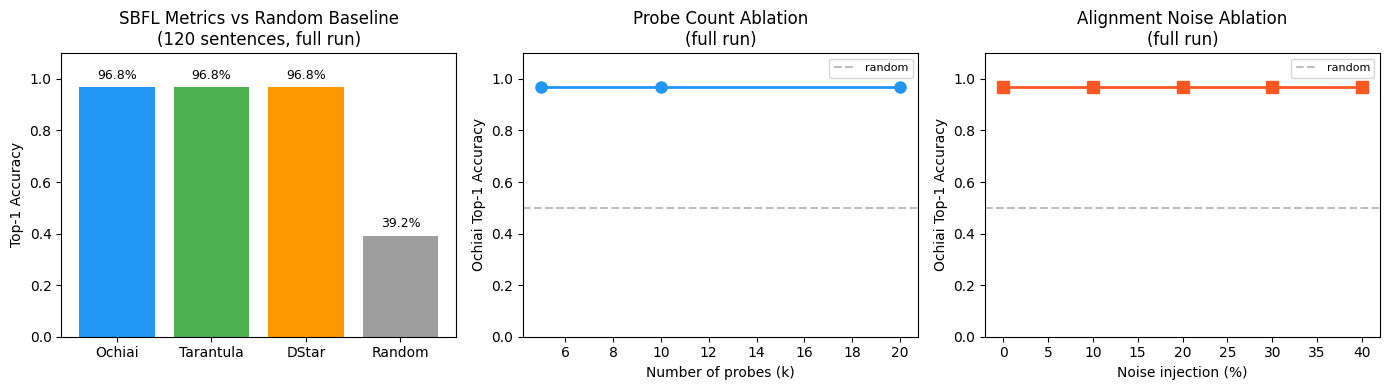


Figure saved to sbfl_fol_results.png


In [13]:
# ── Summary table ──
full_loc = data["metadata"]["localization_results"]
methods = ["ochiai", "tarantula", "dstar", "baseline_random"]
labels  = ["Ochiai", "Tarantula", "DStar", "Random"]

print(f"{'Method':<16} {'Top-1 (demo)':>14} {'Top-1 (full)':>14} {'Top-3 (full)':>14} {'Wasted Effort (full)':>22}")
print("-" * 82)
for mkey, mlabel in zip(methods, labels):
    demo_top1 = localization_results.get(mkey, {}).get("top1", float("nan"))
    full_top1 = full_loc.get(mkey, {}).get("top1", float("nan"))
    full_top3 = full_loc.get(mkey, {}).get("top3", float("nan"))
    full_we   = full_loc.get(mkey, {}).get("wasted_effort", float("nan"))
    print(f"{mlabel:<16} {demo_top1:>14.1%} {full_top1:>14.1%} {full_top3:>14.1%} {full_we:>22.3f}")

print()
print(f"Full-run: {full_loc['local_subset_size']} sentences, Ochiai top-1 = {full_loc['ochiai']['top1']:.1%}, "
      f"wasted effort = {full_loc['ochiai']['wasted_effort']:.4f} (random = 0.500)")
print()

# ── Plots ──
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot 1: Top-1 comparison (full run)
ax = axes[0]
top1_values = [full_loc[m]["top1"] for m in methods]
colors = ["#2196F3", "#4CAF50", "#FF9800", "#9E9E9E"]
bars = ax.bar(labels, top1_values, color=colors)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Top-1 Accuracy")
ax.set_title("SBFL Metrics vs Random Baseline\n(120 sentences, full run)")
for bar, val in zip(bars, top1_values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.1%}",
            ha="center", va="bottom", fontsize=9)

# Plot 2: Probe count ablation (full run)
ax = axes[1]
full_probe_curve = data["metadata"]["ablation_curves"]["probe_count"]
ks = [r["k"] for r in full_probe_curve]
top1s = [r["ochiai_top1"] for r in full_probe_curve]
ax.plot(ks, top1s, "o-", color="#2196F3", linewidth=2, markersize=8)
ax.set_xlabel("Number of probes (k)")
ax.set_ylabel("Ochiai Top-1 Accuracy")
ax.set_title("Probe Count Ablation\n(full run)")
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="random")
ax.legend(fontsize=8)

# Plot 3: Noise ablation (full run)
ax = axes[2]
full_noise = data["metadata"]["ablation_curves"]["alignment_noise"]
noise_pcts = [r["noise_pct"] for r in full_noise]
noise_top1 = [r["ochiai_top1"] for r in full_noise]
ax.plot(noise_pcts, noise_top1, "s-", color="#FF5722", linewidth=2, markersize=8)
ax.set_xlabel("Noise injection (%)")
ax.set_ylabel("Ochiai Top-1 Accuracy")
ax.set_title("Alignment Noise Ablation\n(full run)")
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5, label="random")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("sbfl_fol_results.png", dpi=120, bbox_inches="tight")
plt.show()
print("\nFigure saved to sbfl_fol_results.png")